# Boosting Ensemble Demo on Noisy Synthetic Data

Klasifikatori:
 - **AdaBoost**
  - **XGBoost**

Synth dataset docs: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html



# 1. Priprema dataseta

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import itertools


In [2]:
X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=3, flip_y=0.2, class_sep=0.7, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


df = pd.DataFrame(X, columns=[f"F{i}" for i in range(X.shape[1])])
df["label"] = y

#sns.pairplot(df, hue="label", corner=True, palette="coolwarm")
#plt.suptitle("Pairwise Feature Scatterplots", y=1.02)
#plt.show()


## 2. Usporedba: Stump vs DT vs AdaBoost



In [3]:
def evaluate_model_cv(name, model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{name:20s} Mean Acc: {scores.mean():.3f} | Std: {scores.std():.3f}")
    return scores


Classification Report - stump:

              precision    recall  f1-score   support

     Class 0       0.62      0.49      0.54       301
     Class 1       0.57      0.70      0.63       299

    accuracy                           0.59       600
   macro avg       0.60      0.59      0.59       600
weighted avg       0.60      0.59      0.59       600



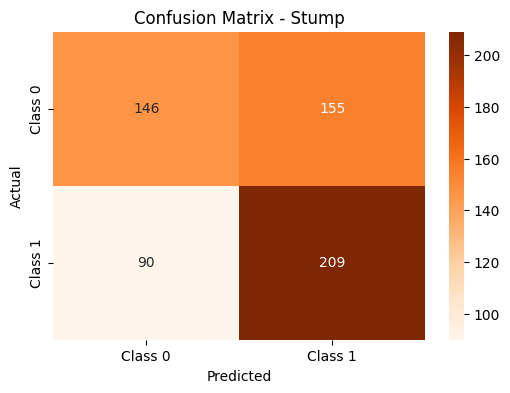

Classification Report - DT:

              precision    recall  f1-score   support

     Class 0       0.70      0.68      0.69       301
     Class 1       0.69      0.70      0.69       299

    accuracy                           0.69       600
   macro avg       0.69      0.69      0.69       600
weighted avg       0.69      0.69      0.69       600



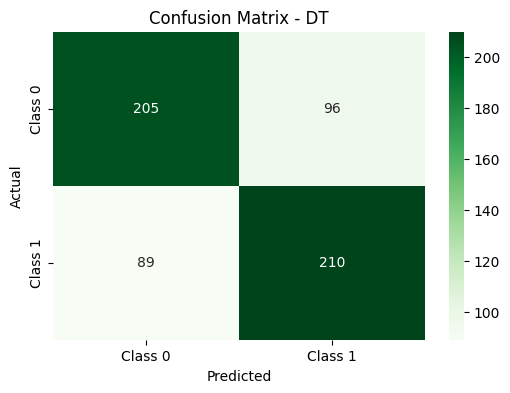

Classification Report - AdaBoost:

              precision    recall  f1-score   support

     Class 0       0.74      0.78      0.76       301
     Class 1       0.76      0.72      0.74       299

    accuracy                           0.75       600
   macro avg       0.75      0.75      0.75       600
weighted avg       0.75      0.75      0.75       600



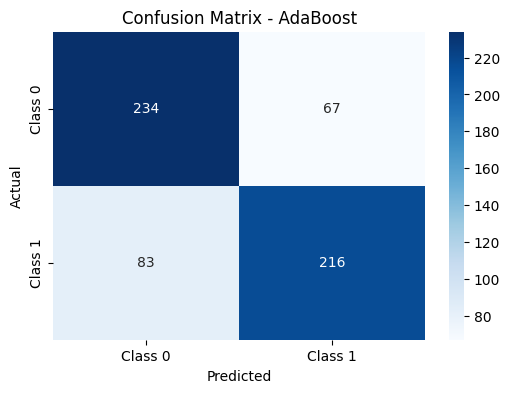

In [4]:
#70-30 split
stump = DecisionTreeClassifier(max_depth=1)
simple_model = DecisionTreeClassifier(max_depth=5, random_state=42)
boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100)

stump.fit(X_train, y_train)
simple_model.fit(X_train, y_train)
boost.fit(X_train, y_train)

y_pred_stump = stump.predict(X_test)
y_pred_simple = simple_model.predict(X_test)
y_pred_boost = boost.predict(X_test)

class_names = [f"Class {i}" for i in np.unique(y)]

print("Classification Report - stump:\n")
print(classification_report(y_test, y_pred_stump, target_names=class_names))
cm = confusion_matrix(y_test, y_pred_stump)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Oranges", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stump")
plt.show()

print("Classification Report - DT:\n")
print(classification_report(y_test, y_pred_simple, target_names=class_names))
cm = confusion_matrix(y_test, y_pred_simple)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greens", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DT")
plt.show()

print("Classification Report - AdaBoost:\n")
print(classification_report(y_test, y_pred_boost, target_names=class_names))
cm = confusion_matrix(y_test, y_pred_boost)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AdaBoost")
plt.show()






Stump                Mean Acc: 0.601 | Std: 0.010
Decision Tree        Mean Acc: 0.692 | Std: 0.015
AdaBoost             Mean Acc: 0.742 | Std: 0.025


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_50616\1697752200.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)


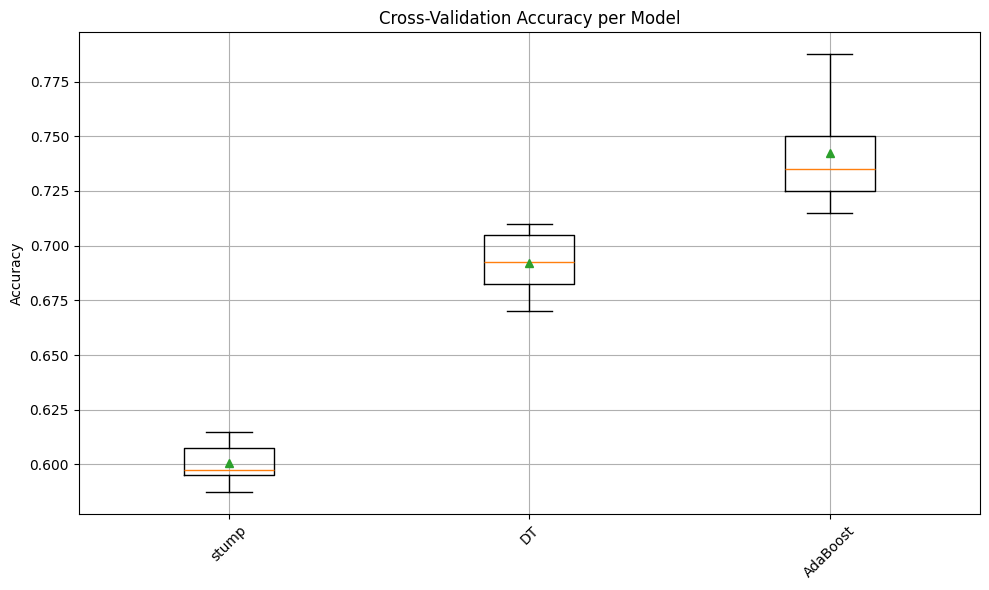

In [5]:
#5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
cv_results["stump"] = evaluate_model_cv("Stump", stump, X, y)
cv_results["DT"] = evaluate_model_cv("Decision Tree", simple_model, X, y)
cv_results["AdaBoost"] = evaluate_model_cv("AdaBoost", boost, X, y)

plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)
plt.title("Cross-Validation Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. AdaBoost Weight Evolution Demo (prvih 5 rundi)
- binary classification
- sve težine iste na početku

In [6]:
X, y = make_classification(n_samples=20, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

n_rounds = 5
weights = np.ones(len(y)) / len(y)
weights_history = [weights.copy()]

# manual boosting loop
for t in range(n_rounds):
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    stump.fit(X, y, sample_weight=weights)

    pred = stump.predict(X)
    miss = (pred != y).astype(int)
    error = np.dot(weights, miss)
    error = max(1e-10, min(error, 1 - 1e-10))
    alpha = 0.5 * np.log((1 - error) / error)

    weights *= np.exp(-alpha * (2 * (y == pred) - 1))
    weights /= weights.sum()
    weights_history.append(weights.copy())

weights_df = pd.DataFrame(weights_history)
weights_df.index.name = "Round"
weights_df.columns = [f"Sample {i}" for i in range(len(y))]

weights_df_display = weights_df.round(4)

print("Sample Weights Over AdaBoost Rounds:\n")
print(weights_df_display)


Sample Weights Over AdaBoost Rounds:

       Sample 0  Sample 1  Sample 2  Sample 3  Sample 4  Sample 5  Sample 6  \
Round                                                                         
0        0.0500    0.0500    0.0500    0.0500    0.0500    0.0500    0.0500   
1        0.1250    0.0312    0.0312    0.1250    0.0312    0.0312    0.0312   
2        0.0769    0.0192    0.0833    0.0769    0.0192    0.0833    0.0192   
3        0.0476    0.0500    0.0516    0.0476    0.0500    0.0516    0.0500   
4        0.1224    0.0310    0.0320    0.1224    0.0310    0.0320    0.0310   
5        0.0888    0.0500    0.0232    0.0888    0.0500    0.0232    0.0500   

       Sample 7  Sample 8  Sample 9  Sample 10  Sample 11  Sample 12  \
Round                                                                  
0        0.0500    0.0500    0.0500     0.0500     0.0500     0.0500   
1        0.0312    0.0312    0.0312     0.0312     0.0312     0.0312   
2        0.0192    0.0192    0.0833     0

## 4. XGBoost



Classification Report - XGB:
              precision    recall  f1-score   support

     Class 0       0.78      0.80      0.79       301
     Class 1       0.80      0.77      0.78       299

    accuracy                           0.79       600
   macro avg       0.79      0.79      0.79       600
weighted avg       0.79      0.79      0.79       600



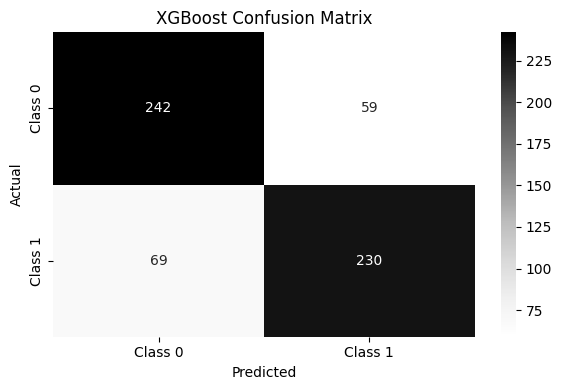

In [7]:
#70-30 split
xgb= XGBClassifier(n_estimators=500, max_depth=5)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

class_names = [f"Class {i}" for i in np.unique(y)]

print("\nClassification Report - XGB:")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Greys", fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()





XGB                  Mean Acc: 0.750 | Std: 0.158


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_50616\2095552994.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)


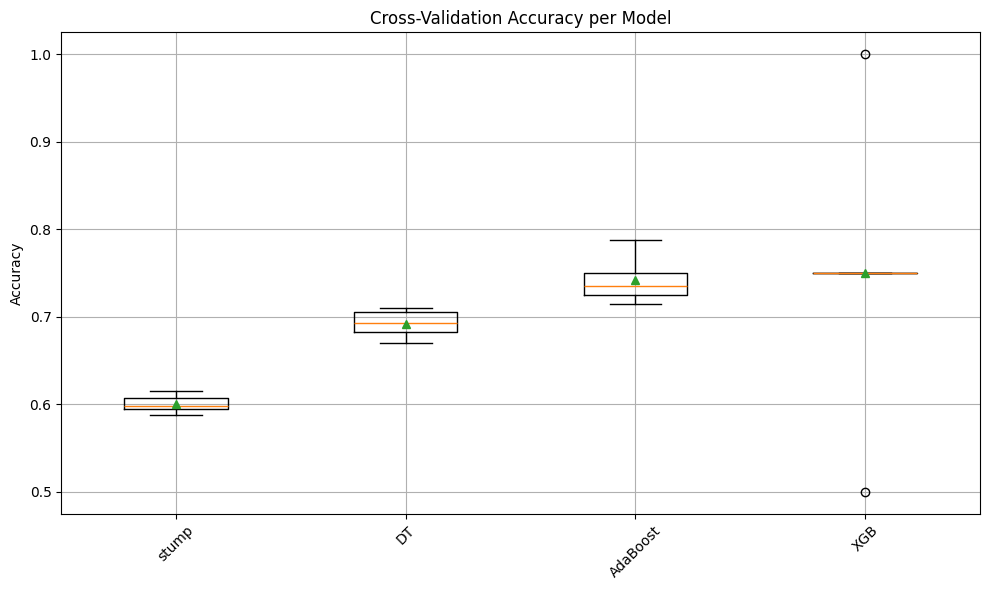

In [8]:
# 5-fold CV
cv_results["XGB"] = evaluate_model_cv("XGB", xgb, X, y)

plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)
plt.title("Cross-Validation Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()




### Learning Curve - vizualizacija
- **Log Loss (Logistic Loss, Cross-Entropy)**:
  - LogLoss(y,p'​)=−[y⋅log(p'​)+(1−y)⋅log(1−p'​)]
    - y - true label
    - p' - predicted probability of class 1
  - a probabilistic loss function which measures how close the predicted probabilities are to the true labels. Penalizes confident wrong answers heavily.
- **Classification Error** = (number of incorrect predictions) / (total predictions)

C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [19:30:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


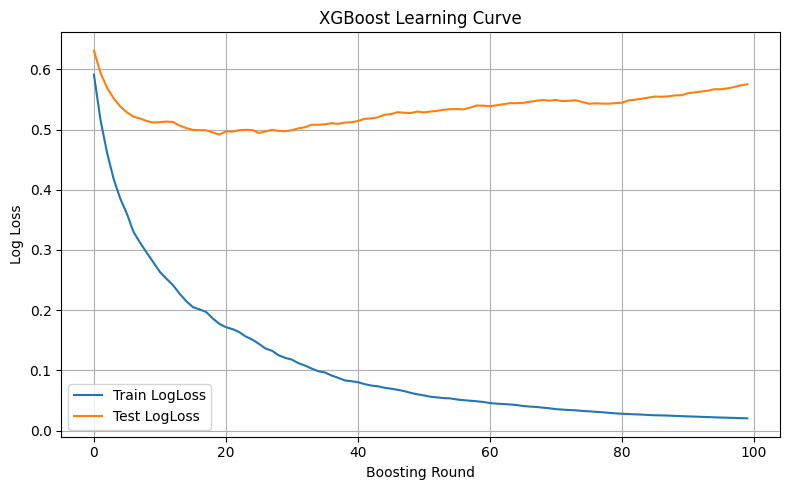

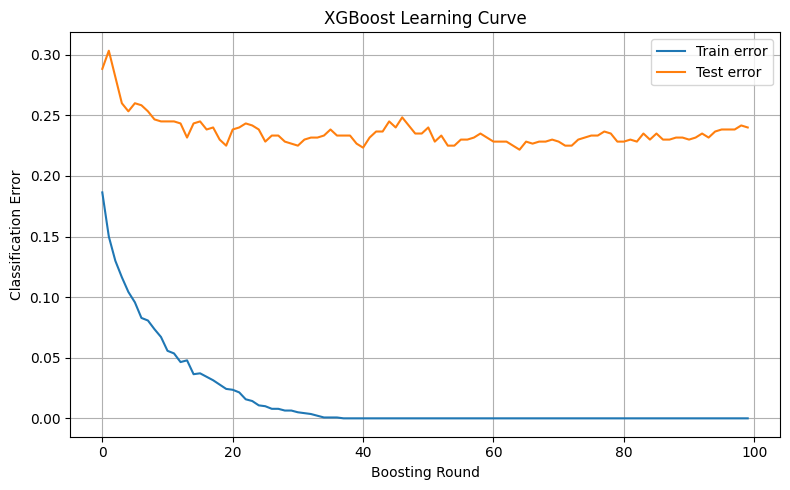

In [9]:
model = XGBClassifier(n_estimators=100, eval_metric=["error", "logloss"], use_label_encoder=False)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

results = model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="Train LogLoss")
plt.plot(results["validation_1"]["logloss"], label="Test LogLoss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["error"], label="Train error")
plt.plot(results["validation_1"]["error"], label="Test error")
plt.xlabel("Boosting Round")
plt.ylabel("Classification Error")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Možemo li bolje? Primjenimo logloss i early_stopping_rounds

[0]	validation_0-logloss:0.58121	validation_1-logloss:0.60874
[1]	validation_0-logloss:0.49172	validation_1-logloss:0.55645
[2]	validation_0-logloss:0.42702	validation_1-logloss:0.51114
[3]	validation_0-logloss:0.38122	validation_1-logloss:0.48316
[4]	validation_0-logloss:0.34017	validation_1-logloss:0.45885
[5]	validation_0-logloss:0.30486	validation_1-logloss:0.43435
[6]	validation_0-logloss:0.28786	validation_1-logloss:0.42965
[7]	validation_0-logloss:0.25700	validation_1-logloss:0.41587
[8]	validation_0-logloss:0.23339	validation_1-logloss:0.41251
[9]	validation_0-logloss:0.22563	validation_1-logloss:0.41097
[10]	validation_0-logloss:0.20982	validation_1-logloss:0.40131
[11]	validation_0-logloss:0.19613	validation_1-logloss:0.39467
[12]	validation_0-logloss:0.18207	validation_1-logloss:0.39394
[13]	validation_0-logloss:0.17365	validation_1-logloss:0.39245
[14]	validation_0-logloss:0.16356	validation_1-logloss:0.39028
[15]	validation_0-logloss:0.15401	validation_1-logloss:0.38829
[1

C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [19:32:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


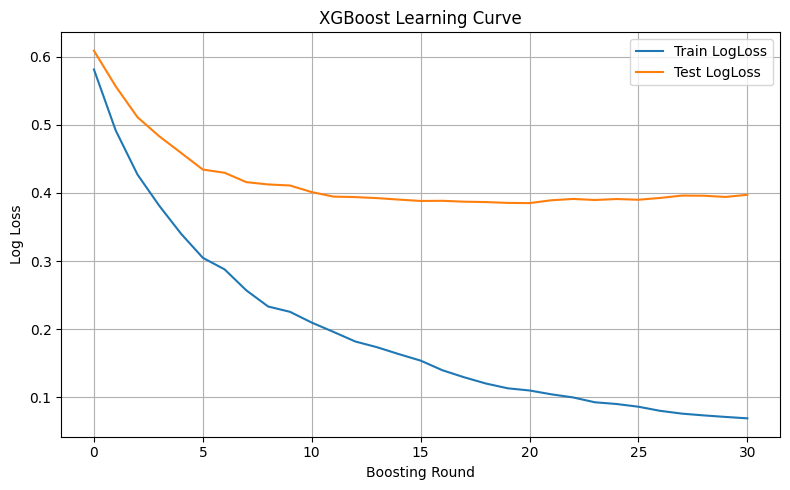


Classification Report - XGB:
              precision    recall  f1-score   support

     Class 0       0.84      0.85      0.85       294
     Class 1       0.86      0.85      0.85       306

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



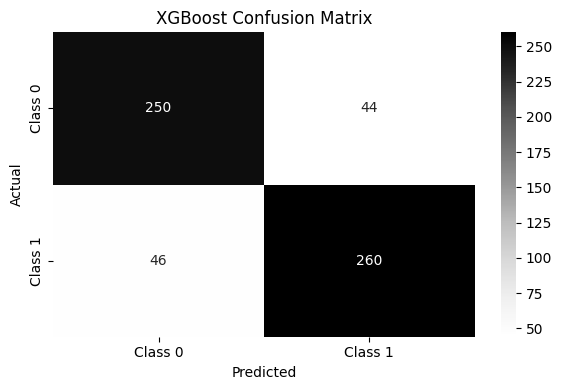

In [12]:
model = XGBClassifier(n_estimators=100, eval_metric="logloss",  early_stopping_rounds=10, use_label_encoder=False)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

print(f"best iteration: { model.best_iteration}")
print(f"best score: {model.best_score}")

results = model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="Train LogLoss")
plt.plot(results["validation_1"]["logloss"], label="Test LogLoss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


model_pred = model.predict(X_test)

class_names = [f"Class {i}" for i in np.unique(y)]

print("\nClassification Report - XGB:")
print(classification_report(y_test, model_pred, target_names=class_names))

cm = confusion_matrix(y_test, model_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Greys", fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()









# 5. Usporedba svih modela


Decision Tree: 0.746 ± 0.021
Stacking: 0.764 ± 0.032
Bagging: 0.806 ± 0.048
AdaBoost: 0.836 ± 0.027
Random Forest: 0.848 ± 0.032
XGBoost: 0.863 ± 0.032


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_50616\1591961510.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True)


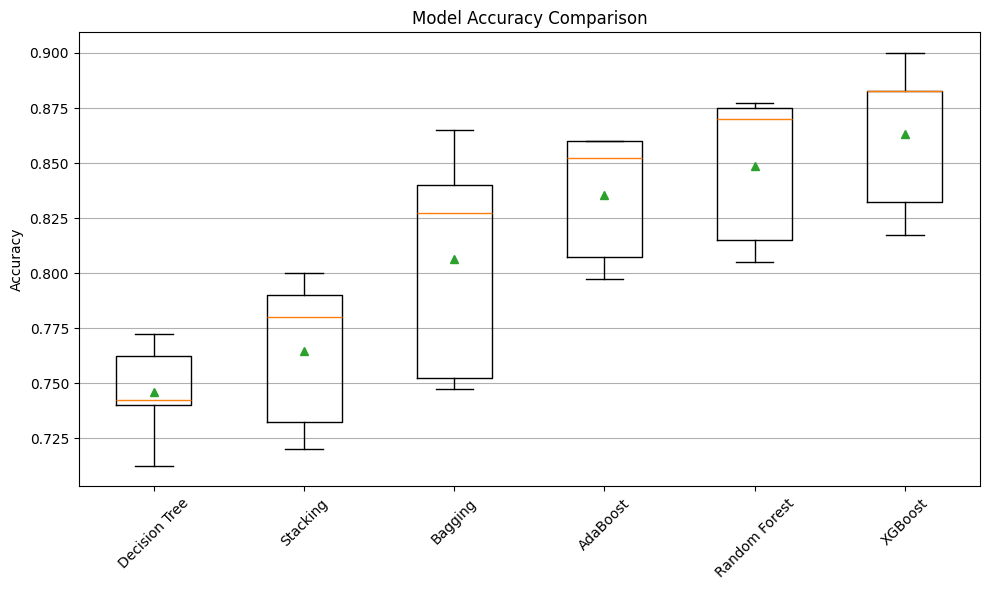

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    StackingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier


X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=5, flip_y=0.1, class_sep=0.8, random_state=42)



models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Stacking": StackingClassifier(
        estimators=[
            ("dt", DecisionTreeClassifier(max_depth=3, random_state=42)),
            ("nb", GaussianNB()),
            ("lr", LogisticRegression(max_iter=1000))
        ],
        final_estimator=LogisticRegression(),
        cv=5,
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=50,
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False,
                             eval_metric="logloss", verbosity=0, random_state=42)
}

#5-fold CV
results = []
names = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    results.append(scores)
    names.append(name)
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")


plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names, showmeans=True)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

